## Introduction

This notebook explores patterns in NYC taxi trips using SQL and Python. 
The analysis focuses on understanding how taxi demand, pricing, and travel behavior vary across time and boroughs.

Key questions explored include:
- How does taxi demand change by hour and day?
- How do trip characteristics differ across boroughs?
- What factors most strongly influence fare?
- How do traffic and trip efficiency vary across locations?

By combining SQL-based aggregation with data visualization, this notebook aims to uncover meaningful insights into how taxi usage and pricing behave in an urban environment.


In [48]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
sns.set_style('whitegrid')

conn=sqlite3.connect('../database/taxi_analysis.db')

## Number of Trips by Pickup Hour

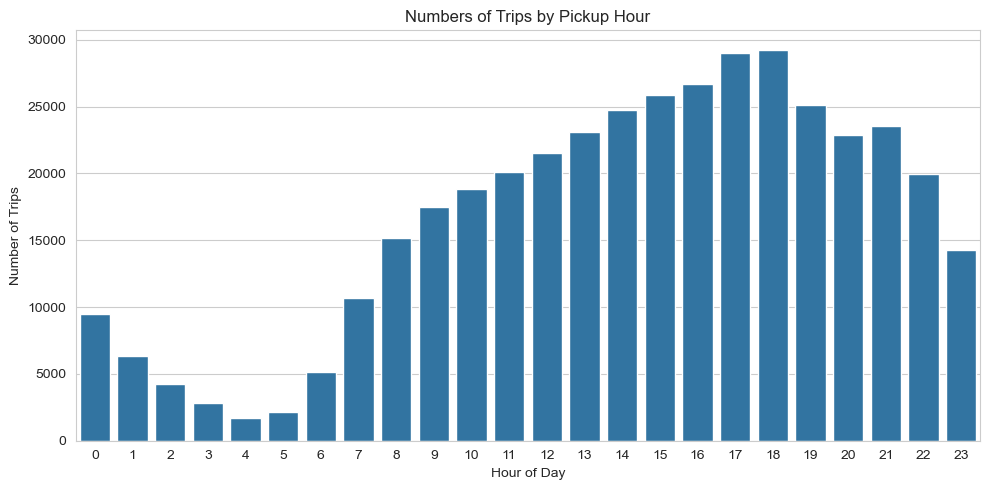

In [3]:
query_trips_by_hour = """
SELECT 
    pickup_hour, 
    COUNT(*) AS trips
FROM trips
GROUP BY pickup_hour
ORDER BY pickup_hour;
"""

df_trips_by_hour = pd.read_sql(query_trips_by_hour,conn)

plt.figure(figsize=(10, 5))
sns.barplot(
    data = df_trips_by_hour,
    x = 'pickup_hour',
    y =  'trips'
)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Numbers of Trips by Pickup Hour')
plt.tight_layout()

**The number of trips changes substantially by hour of day, showing a clear daily travel pattern.** Trip volume is lowest during the overnight and early morning hours, especially from about 2 AM to 5 AM. Demand then increases throughout the morning and afternoon, reaching its peak in the late afternoon to early evening, around 5 PM to 6 PM. After this peak, the number of trips gradually declines into the night. This pattern suggests that taxi usage is strongly influenced by commuting activity and typical daytime movement across the city.

## Number of Trips per Day of Week

Text(0.5, 1.0, 'Number of Trips per Day of Week')

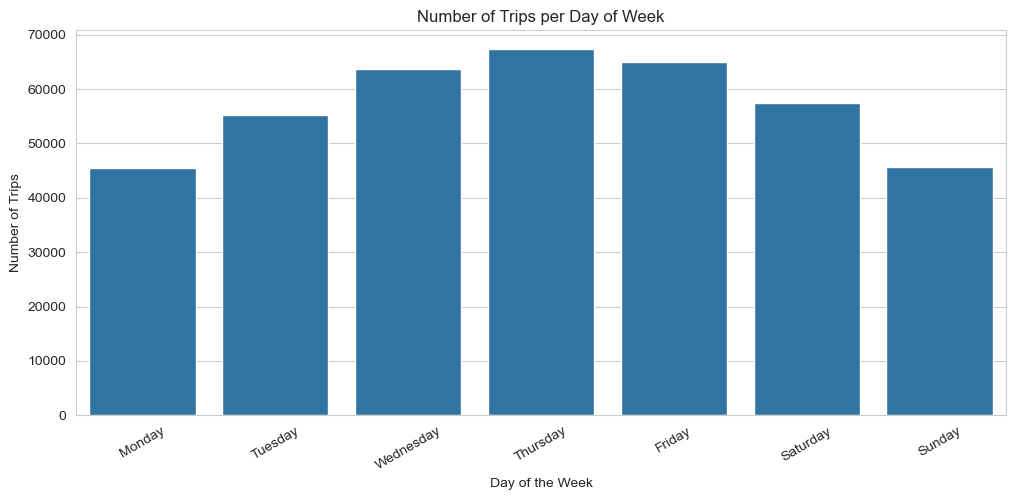

In [10]:
query_trips_per_day = """
SELECT 
    pickup_day,
    COUNT(*) AS trips
FROM trips
GROUP BY pickup_day
ORDER BY pickup_day;
"""

df_trips_per_day = pd.read_sql(query_trips_per_day, conn)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(12,5))

sns.barplot(df_trips_per_day,
            x='pickup_day',
            y = 'trips',
            order = day_order)
plt.tick_params(axis ='x', rotation=30)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Trips')
plt.title('Number of Trips per Day of Week')

**Taxi trip demand shows a clear weekly pattern.** Trip counts are lowest at the beginning of the week and on Sunday, while demand increases through the middle of the week and peaks toward Thursday and Friday. This likely reflects typical urban travel behavior, where commuting and social activity increase toward the end of the workweek before dropping again during the weekend.

## Average Taxi Fare by Pickup Boroug

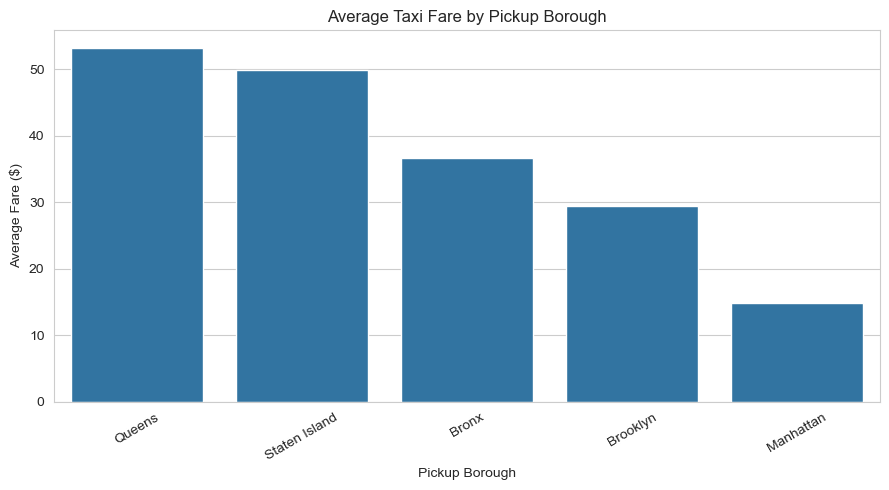

In [13]:
query_avg_fare_by_borough = """
SELECT 
    z.Borough,
    AVG(t.fare_amount) AS avg_fare
FROM trips t
LEFT JOIN zones z
ON t.PUlocationID = z.LocationID
WHERE z.Borough NOT IN ('Unknown', 'EWR')
GROUP BY z.BOROUGH
ORDER BY avg_fare DESC;
"""

df_avg_fare_by_borough = pd.read_sql(query_avg_fare_by_borough, conn)

plt.figure(figsize=(9,5))
sns.barplot(
    data=df_avg_fare_by_borough,
    x = 'Borough',
    y = 'avg_fare'
    )
plt.xticks(rotation=30)
plt.ylabel('Average Fare ($)')
plt.xlabel('Pickup Borough')
plt.title('Average Taxi Fare by Pickup Borough')
plt.tight_layout()

**The average fare differs noticeably across pickup boroughs, suggesting that trip patterns vary by location.** Outer areas such as Queens and Staten Island have higher average fares, which may indicate longer trips on average. In contrast, Manhattan shows the lowest average fare, likely because many rides there are shorter and occur within a more compact area. These results should be interpreted carefully, since average values can be affected by outliers.

## Average Distance, Duration, and Fare, by Pickup Burough

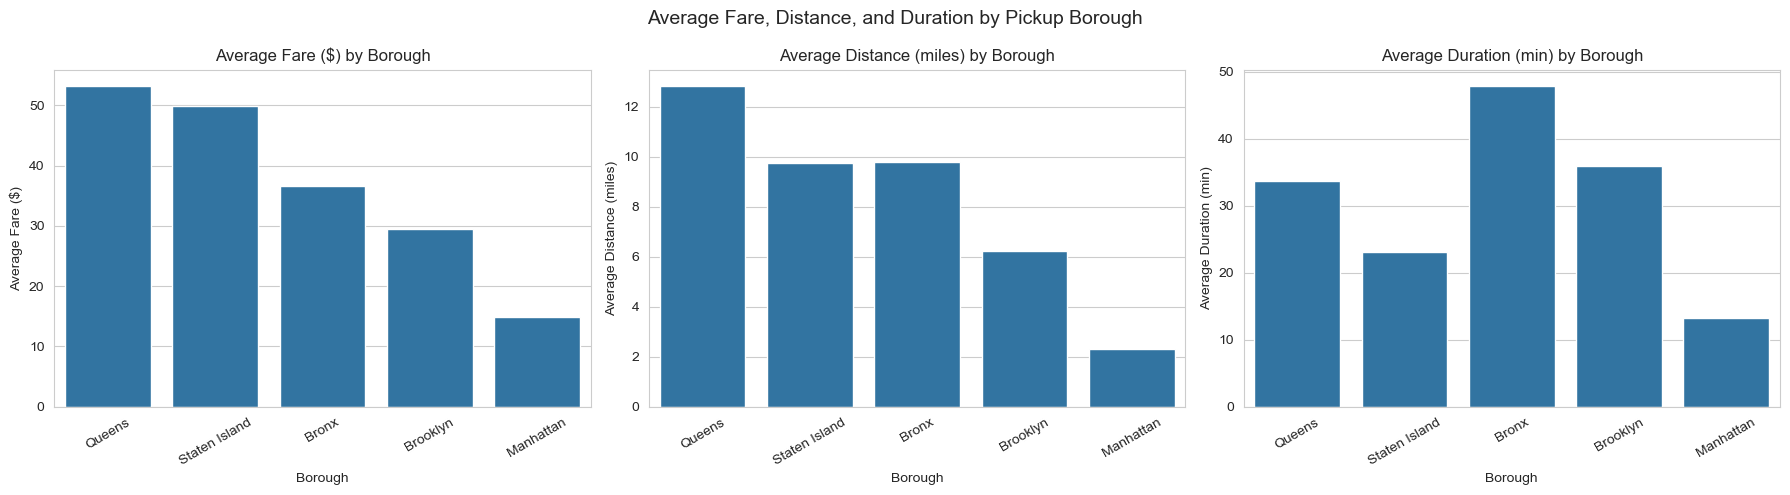

In [18]:
query_avg_fare_duration_distance = """
SELECT
    z.Borough,
    AVG(t.fare_amount) AS avg_fare,
    AVG(t.trip_distance) AS avg_distance,
    AVG(t.trip_duration_min) AS avg_duration
FROM trips t
LEFT JOIN zones z
ON t.PUlocationID = z.locationID
WHERE z.Borough NOT IN ('Unknown', 'EWR')
GROUP BY z.Borough
ORDER BY avg_fare DESC;
"""

df_avg_fare_duration_distance = pd.read_sql(query_avg_fare_duration_distance, conn)

metrics = ['avg_fare', 'avg_distance', 'avg_duration']

rename = {
    'avg_fare': 'Average Fare ($)',
    'avg_distance' : 'Average Distance (miles)',
    'avg_duration' : 'Average Duration (min)'
}

fig, axes = plt.subplots(1,3, figsize=(18,5))
fig.suptitle('Average Fare, Distance, and Duration by Pickup Borough', fontsize=14)

for i, col in enumerate(metrics):

    sns.barplot(
        data = df_avg_fare_duration_distance,
        x='Borough',
        y=col,
        ax = axes[i]
    )
    axes[i].set_title(f'{rename[col]} by Borough')
    axes[i].tick_params(axis='x',  rotation = 30)
    axes[i].set_ylabel(rename[col])
    plt.tight_layout()

**The combined borough comparison shows that fare differences are closely tied to trip distance and duration.** Queens has both the highest average fare and the longest average trip distance, while the Bronx has the highest average trip duration. Manhattan has the lowest values across all three measures, which is consistent with shorter trips on average. These results suggest that location affects taxi prices not only through distance traveled, but also through how long trips take.

## Relationship Between Fare, Distance, and Duration

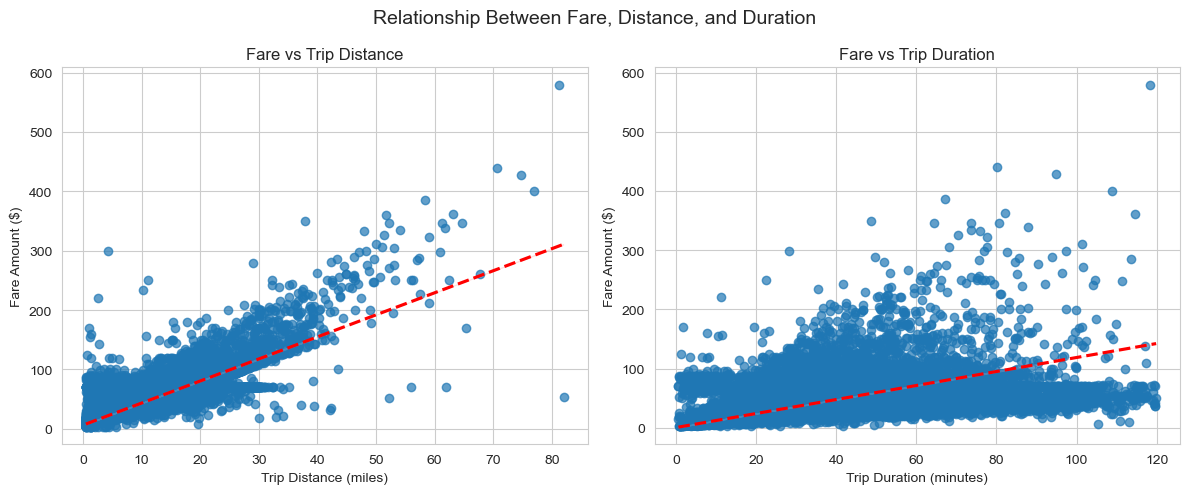

In [44]:
query_fare_distance = """
SELECT
    fare_amount,
    trip_distance,
    trip_duration_min
FROM trips
"""

df_distance_duration_fare = pd.read_sql(query_fare_distance, conn)



fig, axes = plt.subplots(1, 2, figsize = (12,5))
fig.suptitle('Relationship Between Fare, Distance, and Duration', fontsize=14)

sns.regplot(
    data = df_distance_duration_fare,
    x = 'trip_distance',
    y = 'fare_amount',
    scatter_kws = {'alpha':0.7},
    line_kws={'color':'red', 'linestyle': '--'},
    ax = axes[0]
)
axes[0].set_xlabel('Trip Distance (miles)')
axes[0].set_ylabel('Fare Amount ($)')
axes[0].set_title('Fare vs Trip Distance')

sns.regplot(
    data = df_distance_duration_fare,
    x = 'trip_duration_min',
    y = 'fare_amount',
    scatter_kws={'alpha':0.7},
    line_kws={'color':'red', 'linestyle': '--'},
    ax = axes[1]
)
axes[1].set_xlabel('Trip Duration (minutes)')
axes[1].set_ylabel('Fare Amount ($)')
axes[1].set_title('Fare vs Trip Duration')

plt.tight_layout()

**Trip distance shows a strong positive relationship with fare, while trip duration shows a weaker and more variable relationship.** As distance increases, fare rises in a clear and nearly linear pattern, indicating that pricing is largely driven by how far a trip travels. In contrast, trips with similar durations can have a wide range of fares, suggesting that time alone is not the primary determinant of cost. This variability may reflect differences in traffic conditions, routes, or waiting time, but overall distance appears to be the dominant factor influencing fare.

## Average Fare per Mile by Pickup Borough

Text(0.5, 1.0, 'Average Fare per Mile by Pickup Borough')

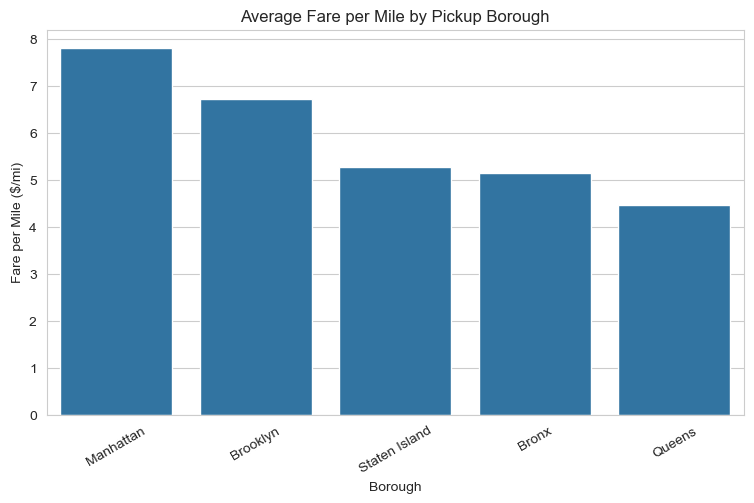

In [28]:
query_fare_per_mile = """
SELECT
    z.Borough,
    AVG(t.fare_amount / NULLIF(t.trip_distance, 0)) AS fare_per_mile
FROM trips t
LEFT JOIN zones z
ON t.PUlocationID = z.locationID
WHERE t.trip_distance > 0.5
  AND z.Borough NOT IN ('Unknown', 'EWR')
GROUP BY z.Borough
ORDER BY fare_per_mile DESC;
"""

df_fare_per_mile = pd.read_sql(query_fare_per_mile, conn)

plt.figure(figsize=(9,5))

sns.barplot(
    data = df_fare_per_mile,
    x = 'Borough',
    y = 'fare_per_mile'
)
plt.ylabel('Fare per Mile ($/mi)')
plt.tick_params(axis='x', rotation=30)
plt.title('Average Fare per Mile by Pickup Borough')

**Fare per mile varies significantly across boroughs, providing insight into how trip characteristics affect pricing.** Manhattan has the highest fare per mile, which likely reflects a high number of short trips where fixed costs and slower travel speeds increase the cost relative to distance. In contrast, Queens has the lowest fare per mile, consistent with longer trips where the cost is spread over greater distances. This reinforces earlier findings that differences in average fare across boroughs are driven not only by distance, but also by trip structure and travel conditions.

## Total Number of Taxi Trips by Pickup Borough

Text(0.5, 1.0, 'Total Number of Taxi Trips by Pickup Borough')

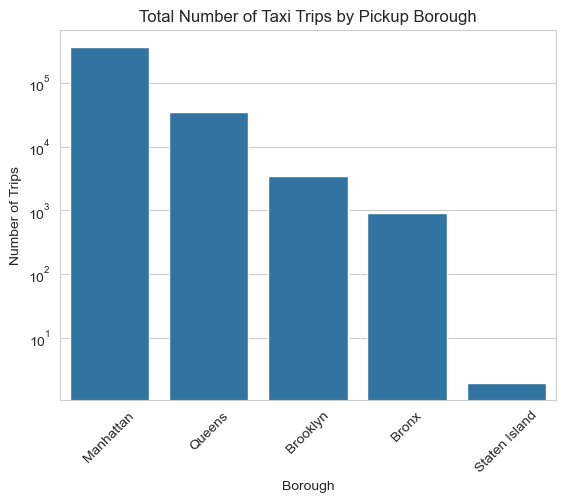

In [30]:
query_trips_by_borough = """
SELECT
    z.Borough,
    COUNT(*) AS trips
FROM trips t
LEFT JOIN zones z
ON t.PUlocationID = z.LocationID
WHERE z.Borough NOT IN ('Unknown', 'EWR')
GROUP BY z.Borough
ORDER BY trips DESC;
"""
 
df_trips_by_borough = pd.read_sql(query_trips_by_borough, conn)

sns.barplot(
    data = df_trips_by_borough,
    x='Borough',
    y='trips'
)
plt.yscale('log')
plt.tick_params(axis = 'x', rotation=45)
plt.xlabel('Borough')
plt.ylabel('Number of Trips')
plt.title('Total Number of Taxi Trips by Pickup Borough')

**Trip volume is heavily concentrated in Manhattan, which accounts for the vast majority of taxi pickups.** Queens has the second-highest number of trips, but at a much lower level, while other boroughs contribute relatively few trips in comparison. This strong imbalance suggests that Manhattan plays a dominant role in overall taxi activity and may heavily influence aggregate trends observed in the dataset.

## Trip Duration vs Distance

Text(0.5, 1.0, 'Trip Duration vs Distance')

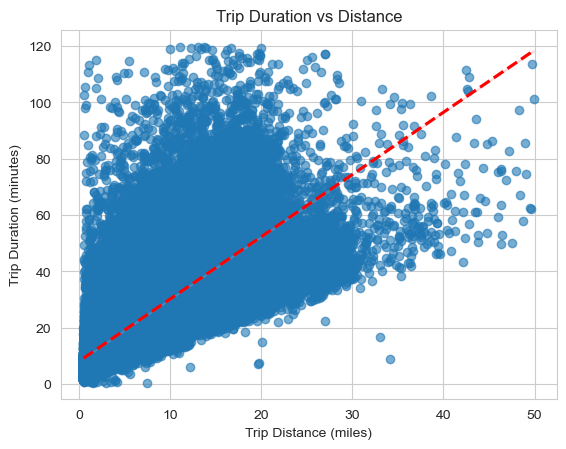

In [43]:
query_duration_vs_distance = """
SELECT 
    z.Borough,
    t.trip_distance,
    t.trip_duration_min
FROM trips t
LEFT JOIN zones z
ON t.PUlocationID = z.locationID
"""

df_duration_vs_distance = pd.read_sql(query_duration_vs_distance, conn)

df_plot = df_duration_vs_distance[
    (df_duration_vs_distance['trip_distance'] > 0) &
    (df_duration_vs_distance['trip_distance'] < 50) &
    (df_duration_vs_distance['trip_duration_min'] > 0) &
    (df_duration_vs_distance['trip_duration_min'] < 120)
]

sns.regplot(
    data=df_plot,
    x='trip_distance',
    y='trip_duration_min',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red', 'linestyle': '--'}
)
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Trip Duration (minutes)')
plt.title('Trip Duration vs Distance')

**Trip duration increases with distance, but the relationship shows significant variability, especially for shorter trips.** While longer trips generally take more time, short-distance trips display a wide range of durations, suggesting that factors such as traffic, stops, and route conditions play a major role. As distance increases, the relationship becomes more consistent, indicating that longer trips are more predictable in terms of travel time. Overall, this suggests that distance alone does not fully explain trip duration, particularly for shorter urban trips.

## Average Minutes per Mile by Borough

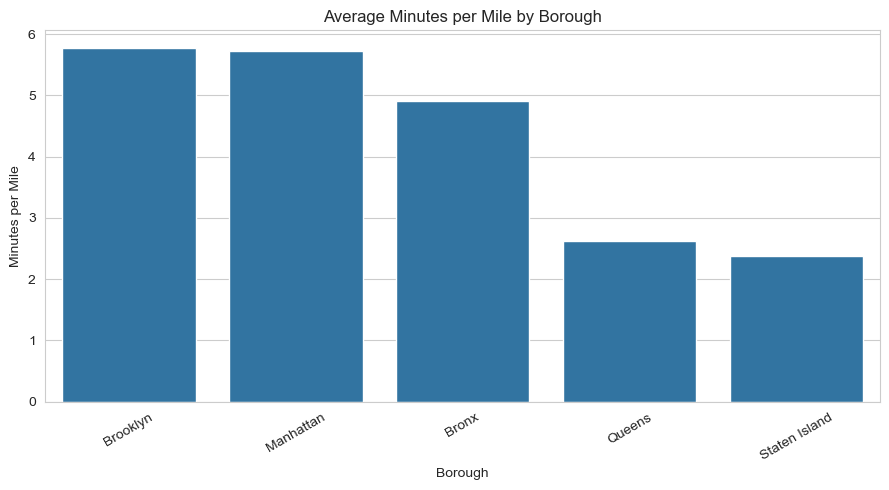

In [46]:
query_duration_vs_distance = """
SELECT
    z.Borough,
    SUM(t.trip_duration_min)/SUM(t.trip_distance) as avg_min_per_mile
FROM trips t
LEFT JOIN zones z
ON t.PUlocationID = z.locationID
WHERE z.Borough NOT IN ('Unknown', 'EWR')
GROUP BY z.Borough
ORDER BY avg_min_per_mile DESC;
"""

df_duration_vs_distance = pd.read_sql(query_duration_vs_distance, conn)

plt.figure(figsize=(9,5))
sns.barplot(
    data=df_duration_vs_distance,
    x='Borough',
    y='avg_min_per_mile'
)

plt.xlabel('Borough')
plt.ylabel('Minutes per Mile')
plt.title('Average Minutes per Mile by Borough')
plt.xticks(rotation=30)
plt.tight_layout()


**Travel efficiency differs substantially across boroughs when measured in minutes per mile.** Brooklyn and Manhattan show the highest values, meaning that riders spend more time traveling for each mile covered. This likely reflects heavier congestion and denser street networks. Queens and Staten Island have much lower minutes-per-mile values, which suggests faster movement and less stop-and-go travel. These results help explain why some boroughs have higher fare per mile despite not having the highest average trip fares.    

## Conclusion

This analysis reveals several key patterns in NYC taxi trips.

Taxi demand follows a clear daily and weekly cycle, with peak activity occurring during the late afternoon and end of the workweek. Trip volume is heavily concentrated in Manhattan, which dominates overall taxi usage and strongly influences aggregate trends.

Fare is most strongly driven by trip distance, showing a clear linear relationship, while trip duration is more variable and influenced by traffic and route conditions. This indicates that pricing is primarily distance-based rather than time-based.

Differences across boroughs highlight how trip structure affects both cost and efficiency. Outer boroughs such as Queens tend to have longer trips and higher average fares, while Manhattan has shorter trips but higher cost per mile. Additionally, Manhattan and Brooklyn show higher minutes per mile, suggesting slower travel speeds and greater congestion.

Overall, these results demonstrate that taxi pricing and travel behavior are shaped by a combination of distance, traffic conditions, and geographic patterns, with Manhattan playing a central role in the system.